Trước hết ta làm rõ thêm định nghĩa và tác dụng của hàm kích hoạt: Activation function (hàm kích hoạt) là một hàm toán học được áp dụng lên đầu ra của mỗi neuron trong mạng neural để quyết định mức độ kích hoạt của neuron đó.Nói ngắn gọn:

Activation function biến đổi giá trị tuyến tính của neuron thành đầu ra (thường phi tuyến) để mạng neural học được các quan hệ phức tạp.


### Nếu không có activation function
Giả sử 1 neuron tính: $$z = w^T x + b$$
Đây chỉ là 1 hàm tuyến tính.
Nếu ta xây nhiều layer nhưng không có activation function: $$z_1 = W_1 x + b_1$$
                                                           $$z_2 = W_2 z_1 + b_2$$
Thay $z_1$ vào phương trình của $z_2$:$$z_2 = W_2(W_1 x + b_1) + b_2$$
                                $$z_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$$      

$\rightarrow$ Vẫn chỉ là một hàm tuyến tính duy nhất.

Dù có 100 layer thì vẫn tương đương:$$y = Wx + b$$

$\rightarrow$ Giống linear regression hoặc linear classifier.
$\rightarrow$ Không học được quan hệ phức tạp.

### Activation function tạo phi tuyến
Khi thêm activation function:$$z = W_1 x + b_1$$
$$a = f(z)$$
$$y = W_2 a + b_2$$
Bây giờ mô hình trở thành:$$y = W_2 f(W_1 x + b_1) + b_2$$
Do $f$ là hàm phi tuyến, nên toàn bộ mô hình không còn tuyến tính.

### Ý nghĩa trong bài toán phân loại
Ví dụ dữ liệu:
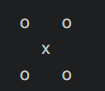

O = class 0

X = class 1

Dữ liệu không tách được bằng đường thẳng.

Nếu không có activation function mô hình chỉ học được:$$ax + by + c = 0$$
$\rightarrow$ linear boundary

$\rightarrow$ không tách được dữ liệu.

Nếu có activation function thì mạng có thể học được biên cong và phân loại đúng


### Hồi quy logicstic
Đầu ra dự đoán của logistic regression thường được viết chung dưới dạng:
$$f(\mathbf{x}) = \theta(\mathbf{w}^T\mathbf{x})$$
Trong đó θ được gọi là logistic function. Một số activation cho mô hình tuyến tính được cho trong hình dưới đây:

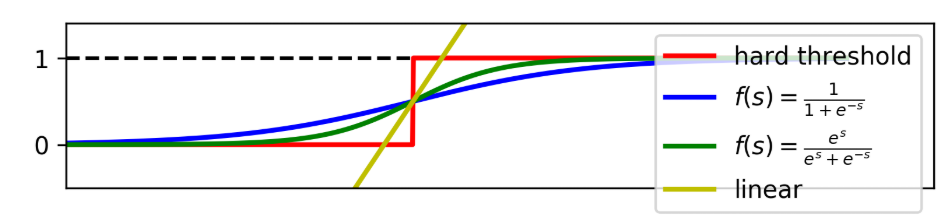

Hàm kích hoạt sigmoid được sử dụng rất phổ biến trong hồi quy logicstic:
$$f(s) = \frac{1}{1 + e^{-s}} \triangleq \sigma(s)$$
vì nó bị chặn trong khoảng $(0, 1)$. Thêm nữa: $$\lim_{s \to -\infty} \sigma(s) = 0; \quad \lim_{s \to +\infty} \sigma(s) = 1$$
Đặc biệt hơn nữa: $$\begin{aligned} \sigma'(s) &= \frac{e^{-s}}{(1 + e^{-s})^2} \\ &= \frac{1}{1 + e^{-s}} \frac{e^{-s}}{1 + e^{-s}} \\ &= \sigma(s)(1 - \sigma(s)) \end{aligned}$$Công thức đạo hàm đơn giản thế này giúp hàm số này được sử dụng rộng rãi. 

Ngoài ra, hàm tanh cũng hay được sử dụng: $$\tanh(s) = \frac{e^s - e^{-s}}{e^s + e^{-s}}$$ Hàm số này nhận giá trị trong khoảng $(-1, 1)$ nhưng có thể dễ dàng đưa nó về khoảng $(0, 1)$.

Ta dễ dàng chứng minh được: $$\tanh(s) = 2\sigma(2s) - 1$$

## Hàm mất mát và phương pháp tối ưu
#### Xây dựng hàm mất mát

Với mô hình như trên (các activation màu xanh lam và lục), ta có thể giả sử rằng xác suất để một điểm dữ liệu $\mathbf{x}$ rơi vào class 1 là $f(\mathbf{w}^T \mathbf{x})$ và rơi vào class 0 là $1 - f(\mathbf{w}^T \mathbf{x})$. Với mô hình được giả sử như vậy, với các điểm dữ liệu training (đã biết đầu ra $y$), ta có thể viết như sau:

$$P(y_i = 1 | \mathbf{x}_i; \mathbf{w}) = f(\mathbf{w}^T \mathbf{x}_i) \quad (1)$$ $$P(y_i = 0 | \mathbf{x}_i; \mathbf{w}) = 1 - f(\mathbf{w}^T \mathbf{x}_i) \quad (2)$$ Trong đó $P(y_i = 1 | \mathbf{x}_i; \mathbf{w})$ được hiểu là xác suất xảy ra sự kiện đầu ra $y_i = 1$ khi biết tham số mô hình $\mathbf{w}$ và dữ liệu đầu vào $\mathbf{x}_i$. 
Mục đích của chúng ta là tìm các hệ số $\mathbf{w}$ sao cho $f(\mathbf{w}^T \mathbf{x}_i)$ càng gần với 1 càng tốt với các điểm dữ liệu thuộc class 1 và càng gần với 0 càng tốt với những điểm thuộc class 0.Ký hiệu $z_i = f(\mathbf{w}^T \mathbf{x}_i)$ và viết gộp lại hai biểu thức bên trên ta có:$$P(y_i | \mathbf{x}_i; \mathbf{w}) = z_i^{y_i}(1 - z_i)^{1 - y_i}$$
Biểu thức này là tương đương với hai biểu thức (1) và (2) ở trên vì khi $y_i = 1$, phần thứ hai của vế phải sẽ triệt tiêu, khi $y_i = 0$, phần thứ nhất sẽ bị triệt tiêu! Chúng ta muốn mô hình gần với dữ liệu đã cho nhất, tức xác suất này đạt giá trị cao nhất.Xét toàn bộ training set với $\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N] \in \mathbb{R}^{d \times N}$ và $\mathbf{y} = [y_1, y_2, \dots, y_N]$, chúng ta cần tìm $\mathbf{w}$ để biểu thức sau đây đạt giá trị lớn nhất:$$P(\mathbf{y} | \mathbf{X}; \mathbf{w})$$Ở đây, ta cũng ký hiệu $\mathbf{X}, \mathbf{y}$ như các biến ngẫu nhiên (random variables). Nói cách khác:$$\mathbf{w} = \arg \max_{\mathbf{w}} P(\mathbf{y} | \mathbf{X}; \mathbf{w})$$

Giả sử thêm rằng các điểm dữ liệu được sinh ra một cách ngẫu nhiên độc lập với nhau (independent), ta có thể viết:
$$\begin{aligned}P(\mathbf{y}|\mathbf{X}; \mathbf{w}) &= \prod_{i=1}^{N} P(y_i|\mathbf{x}_i; \mathbf{w}) \\
&= \prod_{i=1}^{N} z_i^{y_i} (1 - z_i)^{1-y_i}
\end{aligned}$$

Trực tiếp tối ưu hàm số này theo $\mathbf{w}$ nhìn qua không đơn giản! Hơn nữa, khi $N$ lớn, tích của $N$ số nhỏ hơn 1 có thể dẫn tới sai số trong tính toán (numerical error) vì tích là một số quá nhỏ.Một phương pháp thường được sử dụng đó là lấy logarit tự nhiên (cơ số $e$) của likelihood function để biến phép nhân thành phép cộng và tránh việc số quá nhỏ. Sau đó lấy ngược dấu để được một hàm và coi nó là hàm mất mát. Lúc này bài toán tìm giá trị lớn nhất (maximum likelihood) trở thành bài toán tìm giá trị nhỏ nhất của hàm mất mát (hàm này còn được gọi là negative log likelihood):
$$\begin{aligned}
J(\mathbf{w}) &= -\log P(\mathbf{y}|\mathbf{X}; \mathbf{w}) \\
&= -\sum_{i=1}^{N} (y_i \log z_i + (1 - y_i) \log(1 - z_i))
\end{aligned}$$

Chú ý: Trong machine learning, logarit thập phân ít được dùng, vì vậy $\log$ thường được dùng để ký hiệu logarit tự nhiên.

#### Tối ưu hàm mất mát

Chúng ta sử dụng phương pháp Stochastic Gradient Descent (SGD) ở đây. Hàm mất mát với chỉ một điểm dữ liệu $(x_i, y_i)$ là:
$$J(\mathbf{w}; \mathbf{x}_i, y_i) = -(y_i \log z_i + (1 - y_i) \log(1 - z_i))$$Với đạo hàm:$$\begin{aligned}
\frac{\partial J(\mathbf{w}; \mathbf{x}_i, y_i)}{\partial \mathbf{w}} &= -\left(\frac{y_i}{z_i} - \frac{1 - y_i}{1 - z_i}\right) \frac{\partial z_i}{\partial \mathbf{w}} \\
&= \frac{z_i - y_i}{z_i(1 - z_i)} \frac{\partial z_i}{\partial \mathbf{w}} \quad (3)
\end{aligned}$$Để cho biểu thức này trở nên gọn và đẹp hơn, chúng ta sẽ tìm hàm $z = f(\mathbf{w}^T \mathbf{x})$ sao cho mẫu số bị triệt tiêu. Nếu đặt $s = \mathbf{w}^T \mathbf{x}$, chúng ta sẽ có:$$\frac{\partial z_i}{\partial \mathbf{w}} = \frac{\partial z_i}{\partial s} \frac{\partial s}{\partial \mathbf{w}} = \frac{\partial z_i}{\partial s} \mathbf{x}$$Một cách trực quan nhất, ta sẽ tìm hàm số $z = f(s)$ sao cho:$$\frac{\partial z}{\partial s} = z(1 - z) \quad (4)$$để triệt tiêu mẫu số trong biểu thức (3). Chúng ta cùng khởi động một chút với phương trình vi phân đơn giản này. Phương trình (4) tương đương với:
$$\begin{aligned}
\frac{\partial z}{z(1 - z)} &= \partial s \\
\Leftrightarrow \left( \frac{1}{z} + \frac{1}{1 - z} \right) \partial z &= \partial s \\
\Leftrightarrow \log z - \log(1 - z) &= s \\
\Leftrightarrow \log \frac{z}{1 - z} &= s \\
\Leftrightarrow \frac{z}{1 - z} &= e^s \\
\Leftrightarrow z &= e^s(1 - z) \\
\Leftrightarrow z = \frac{e^s}{1 + e^s} &= \frac{1}{1 + e^{-s}} = \sigma(s)
\end{aligned}$$

Đến đây, ta đã hiểu hàm số sigmoid được tạo ra như thế nào.

Chú ý: Trong việc giải phương trình vi phân ở trên, đã bỏ qua hằng số khi lấy nguyên hàm hai vế. Tuy vậy, việc này không ảnh hưởng nhiều tới kết quả.

#### Công thức cập nhật cho logistic sigmoid regression

$$\frac{\partial J(\mathbf{w}; \mathbf{x}_i, y_i)}{\partial \mathbf{w}} = (z_i - y_i)\mathbf{x}_i$$
Quá Và công thức cập nhật (theo thuật toán SGD - Stochastic Gradient Descent) cho logistic regression là:
$$\mathbf{w} = \mathbf{w} + \eta(y_i - z_i)\mathbf{x}_i$$

### ví dụ 1 bài toán bằng python
Một nhóm 20 sinh viên dành thời gian trong khoảng từ 0 đến 6 giờ cho việc ôn thi. Thời gian ôn thi này ảnh hưởng đến xác suất sinh viên vượt qua kỳ thi như thế nào? 


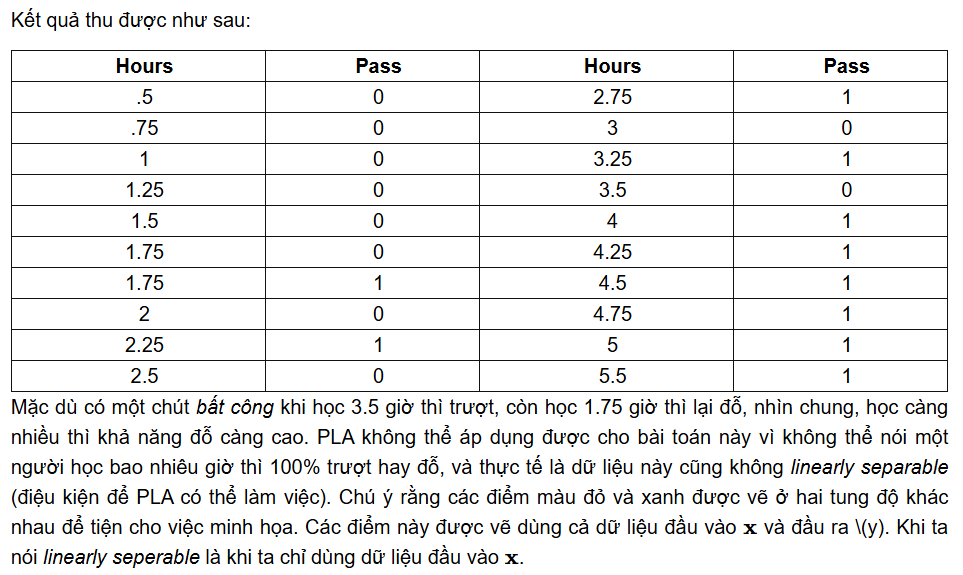

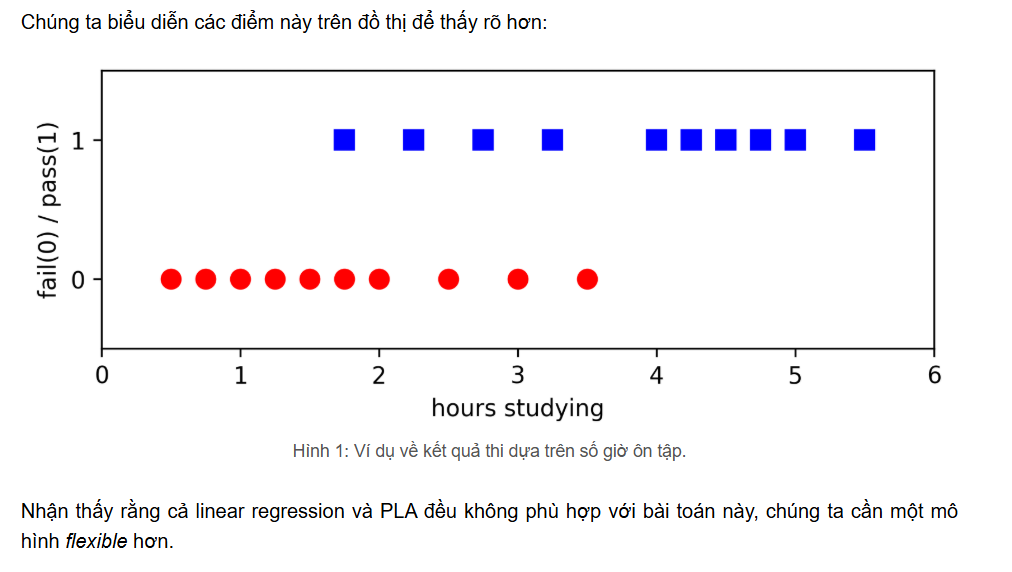




In [5]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

### Các hàm cần thiết cho logistic sigmoid regression

In [6]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data 
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])

[[-4.092695  ]
 [ 1.55277242]]


Với kết quả tìm được, đầu ra y có thể được dự đoán theo công thức: y = sigmoid(-4.1 + 1.55*x). Với dữ liệu trong tập training, kết quả là:

In [7]:
print(sigmoid(np.dot(w[-1].T, X)))

[[0.03501592 0.05078108 0.07310642 0.10416972 0.14634799 0.20175793
  0.20175793 0.27147534 0.35458234 0.4475032  0.54424128 0.63775242
  0.72188183 0.79282004 0.89267823 0.92460236 0.94758783 0.96384008
  0.97518471 0.9884283 ]]


Biểu diễn kết quả trên đồ thị:

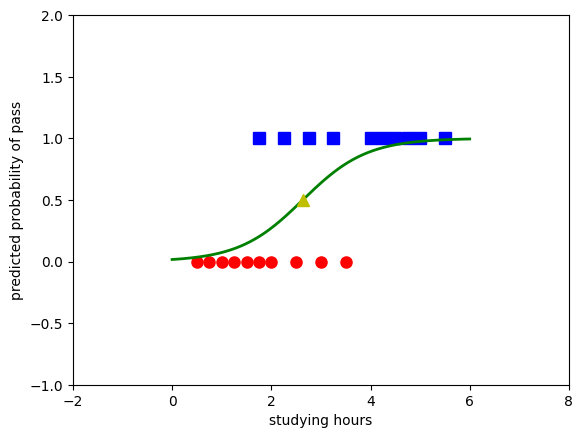

In [8]:
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

## Một vài tính chất của Logistic Regression

#### Logistic Regression thực ra được sử dụng nhiều trong các bài toán Classification.

Mặc dù có tên là Regression, tức một mô hình cho fitting, Logistic Regression lại được sử dụng nhiều trong các bài toán Classification. Sau khi tìm được mô hình, việc xác định class $y$ cho một điểm dữ liệu $\mathbf{x}$ được xác định bằng việc so sánh hai biểu thức xác suất:$$P(y = 1|\mathbf{x}; \mathbf{w}); \quad P(y = 0|\mathbf{x}; \mathbf{w})$$Nếu biểu thức thứ nhất lớn hơn thì ta kết luận điểm dữ liệu thuộc class 1, ngược lại thì nó thuộc class 0. Vì tổng hai biểu thức này luôn bằng 1 nên một cách gọn hơn, ta chỉ cần xác định xem $P(y = 1|\mathbf{x}; \mathbf{w})$ lớn hơn 0.5 hay không. Nếu có, class 1. Nếu không, class 0.Boundary tạo bởi Logistic Regression có dạng tuyến tínhThật vậy, theo lập luận ở phần trên thì chúng ta cần kiểm tra:$$\begin{aligned} &P(y = 1|\mathbf{x}; \mathbf{w}) > 0.5 \\ \Leftrightarrow &\frac{1}{1 + e^{-\mathbf{w}^T\mathbf{x}}} > 0.5 \\ \Leftrightarrow &e^{-\mathbf{w}^T\mathbf{x}} < 1 \\ \Leftrightarrow &\mathbf{w}^T\mathbf{x} > 0 \end{aligned}$$Nói cách khác, boundary giữa hai class là đường có phương trình $\mathbf{w}^T\mathbf{x}$. Đây chính là phương trình của một siêu mặt phẳng. Vậy Logistic Regression tạo ra boundary có dạng tuyến tính.